# bert

In [1]:
#NER
path_geral_ner = './legalbert-pt/model/'
file_tags_ner = path_geral_ner + 'tags.npy'
file_modelo_ner = path_geral_ner + 'geral_130522finetuned_legalbertpt_epoch_8.tar'
file_abreviaturas_ner = path_geral_ner + 'abbrev_list.pkl'
path_saida_ner = './saida'
#path_validacao_kgl = path_geral_ner + 'validacaoLegislacao'

path_saida_validacao_ner_kgl = path_geral_ner + 'validacao_ner_kgl/'
#TODO: Verificar o nome do arquivo
path_saida_validacao_ner_kgl += '1.json'

In [2]:
#NER
from nltk import word_tokenize
from nltk.tokenize.punkt import PunktSentenceTokenizer, PunktParameters

def ajusta_transicao_entidades(toplevel_preds, str_rep):
  for id, pred in enumerate(toplevel_preds):
     if pred.startswith('I-'):
      if id == 0:
        toplevel_preds[id] = 'B-' + pred[2:]

      #Transição I-A I-B ou B-A I-B
      if id+1 > len(toplevel_preds):
        if not toplevel_preds[id-1] == 'O' and toplevel_preds[id-1][2:] != pred[2:]:
          if not toplevel_preds[id+1].startswith('I-') or \
            (toplevel_preds[id+1].startswith('I-') and toplevel_preds[id+1][2:] == toplevel_preds[id-1][2:]):
            toplevel_preds[id] = 'I-' + toplevel_preds[id-1][2:]
          elif toplevel_preds[id+1].startswith('I-') and toplevel_preds[id+1] == pred:
            toplevel_preds[id] = 'B-' + pred[2:]

      #Transição O I
      if toplevel_preds[id-1] == 'O':
          encontrouAnterior = False
          #print(id-1, id-3)
          for id_ant in range(id-1, id-5, -1): #Janela: 3
            if id_ant == -1:
              break
            if toplevel_preds[id_ant] != 'O':
              if toplevel_preds[id_ant][2:] == pred[2:]:
                for i in range(id_ant+1, id-1+1):
                  toplevel_preds[i] = 'I-' + pred[2:]
                encontrouAnterior = True
                break
          if not encontrouAnterior:
            toplevel_preds[id] = 'B-' + pred[2:]
     
     if len(pred) > 1 and \
      (id == 0 or toplevel_preds[id-1] == 'O') and \
      (id == len(toplevel_preds)-1 or toplevel_preds[id+1] == 'O' or toplevel_preds[id+1].startswith('B-')) and \
      (len(str_rep[id]) == 1 or (pred[2:].startswith('NOR'))):
      toplevel_preds[id] = 'O'
  return toplevel_preds

In [3]:
import re

def YY2YYYY(match):
    s0 = match.groups()[0]
    s1 = match.groups()[1]
    s2 = match.groups()[2]
    
    if int(s2) <= 22:
        return r'{}{}20{}'.format(s0,s1,s2)
    else:
        return r'{}{}19{}'.format(s0,s1,s2)

def trata_texto_ner(texto):
    # tira espaços do início e do fim
    texto = texto.strip()
    
    # remove o número das leis
    texto = re.sub(r'\b[nN][.]?[º°][.]?[ ]?',
                   r' ',
                   texto)
    
    texto = texto.replace('seuArtigo', 'seu Artigo')
    texto = texto.replace('doArtigo', 'do Artigo')
    
    # remove o grau dos números
    texto = re.sub(r'(\d)[º°][.]?',
                   r'\1',
                   texto)

    # tira espaços e caracteres _ e = duplicados
    texto = re.sub(r'[\s_=]+',
                   ' ',
                   texto)
    
    # padroniza "Decreto-Lei"
    texto = re.sub(r'([Dd]ecreto)\s?\-?\s?([Ll]ei)',
                   r'\1-\2',
                   texto)

    # tira eventuais espaços extras antes e depois de ".", "/" ou "-"
    texto = re.sub(r'(\d)\s?([.\/\-])\s?(\d)',
                   r'\1\2\3',
                   texto)
    
    # padroniza o ano de 2 dígitos para 4 dígitos
    texto = re.sub(r'(\d{1,3}(?:\.\d{3})*)(\/)(\d{2})\b',
                   YY2YYYY,
                   texto)
    
    # Padroniza a abreviação dos artigos
    texto = re.sub(r' (Art)\D+0* (\d+)',r' Artigo \2',texto, flags=re.I)

    # Padroniza o início dos caracteres das Leis
    texto = re.sub(r'\b(lei)\b', r'Lei',texto, flags=re.I)
    
    # padroniza as abreviações de leis
    d = {'CP': 'Código Penal',
         'CPM': 'Código Penal Militar',
         'CPC': 'Código de Processo Civil',
         'CF': 'Constituição Federal',
         'CC': 'Código Civil',
         'CDC': 'Código de Defesa do Consumidor',
         'CTN': 'Código Tributário Nacional',
         'LDB': 'Lei de Diretrizes e Bases da Educação Nacional',
         'CPP': 'Código de Processo Penal',
         'CPPM': 'Código de Processo Penal Militar',
         'ECA': 'Estatuto da Criança e do Adolescente',
         'LEP': 'Lei de Execução Penal',
         'PNE': 'Plano Nacional de Educação',
         'LRF': 'Lei de Responsabilidade Fiscal',
         'LOAS': 'Lei Orgânica da Assistência Social',
         'CTB': 'Código de Trânsito Brasileiro',
         'CPB': 'Código Penal Brasileiro',
         'CRFB': 'Constituição Federal',
         'CFC': 'Conselho Federal de Contabilidade',
          # Padroniza as leis pelo nome
         'Decreto-Lei 2.848/1940': 'Código Penal',
         'Decreto-Lei 1.001/1969': 'Código Penal Militar',
         'Lei 5.869/1973': 'Código de Processo Civil', 
         'Lei 13.105/2015': 'Código de Processo Civil',
         'Lei 4.737/1965': 'Código Eleitoral',
         'Lei 10.406/2002': 'Código Civil',
         'Lei 8.078/1990': 'Código de Defesa do Consumidor', 
         'Lei 5.172/1966': 'Código Tributário Nacional',
         'Lei 9.394/1996': 'Lei de Diretrizes e Bases da Educação Nacional',
         'Decreto-Lei 3.689/1941': 'Código de Processo Penal',
         'Decreto-Lei 1.002/1969': 'Código de Processo Penal Militar',
         'Lei 8.069/1990': 'Estatuto da Criança e do Adolescente',
         'Lei 7.210/1984': 'Lei de Execução Penal',
         'Decreto-Lei 5.452/1943': 'Consolidação das Leis do Trabalho',
         'Lei 9.053/1997': 'Código de Trânsito Brasileiro',
         'Lei 12.651/2012': 'Código Florestal', 
         'Decreto 24.643/1934': 'Código de Águas',
         'Decreto-Lei 227/1967': 'Código de Minas',
         'Lei 7.565/1986': 'Código Brasileiro de Aeronáutica',
         'Lei 4.117/1962': 'Código Brasileiro de Telecomunicações',
         'Lei 8.906/1994': 'Estatuto da Advocacia e da Ordem dos Advogados do Brasil',
         'Lei 10.257/2001': 'Estatuto da Cidade',
         'Lei 10.671/2003': 'Estatuto de Defesa do Torcedor',
         'Lei 10.826/2003': 'Estatuto do Desarmamento',
         'Lei 13.445/2017': 'Estatuto do Estrangeiro',
         'Lei 10.741/2003': 'Estatuto do Idoso',
         'Lei 12.288/2010': 'Estatuto da Igualdade Racial',
         'Lei 6.001/1973': 'Estatuto do Índio',
         'Lei 12.852/2013': 'Estatuto da Juventude',
         'Lei 6.880/1980': 'Estatuto dos Militares',
         'Lei 11.904/2009': 'Estatuto dos Museus',
         'Lei Complementar 123/2006': 'Estatuto Nacional da Microempresa e da Empresa de Pequeno Porte',
         'Lei 13.146/2015': 'Estatuto da Pessoa com Deficiência',
         'Lei 9.474/1997': 'Estatuto dos Refugiados',
         'Lei 4.504/1964': 'Estatuto da Terra',
         'Lei 11.340/2006': 'Lei Maria da Penha', 
         'Lei 11.343/2006': 'Lei Antidrogas',
         'Lei 12.318/2010': 'Lei de Alienação Parental',
         'Lei 6.766/1979': 'Lei do Parcelamento do Solo Urbano',
         'Lei 13.257/2016': 'Marco Legal da Primeira Infância',
         'Lei 13.005/2014': 'Plano Nacional de Educação',
         'Lei 8.842/1994': 'Política Nacional do Idoso',  
         'Medida Provisória 795/2017': 'MP do Trilhão',
         'Lei 8.742/1993': 'Lei Orgânica da Assistência Social',
         'Lei 9.870/1999': 'Lei do Calote',
         'Lei 11.771/2008': 'Lei Geral do Turismo',
         'Lei 6.938/1981': 'Política Nacional do Meio Ambiente',
         'Lei 9.433/1997': 'Política Nacional de Recursos Hídricos',
         'Lei Complementar 64/1990': 'Lei das Inelegibilidades',
         'Lei 9.504/1997': 'Lei das Eleições',
         'Lei Complementar 101/2000': 'Lei de Responsabilidade Fiscal',
         'Lei 9.492/1997': 'Lei de Protesto de Títulos',
         'Lei 9.474/1997': 'Estatuto dos Refugiados de 1951',
         'Lei 13.819/2019': 'Política Nacional de Prevenção da Automutilação e do Suicídio'
         }
    
    for chave,valor in d.items():
        texto = re.sub(r'\b{}\b'.format(chave),
                       r'{}'.format(valor),
                       texto, flags=re.I)
    
    return texto

In [4]:
device = 'cpu'

In [5]:
#NER
from transformers import BertForTokenClassification, BertTokenizer
import numpy as np
import torch
import pickle

def get_tags_ner():
  tag2idx_ner = np.load(file_tags_ner, allow_pickle=True).item()
  idx2tag_ner = {}
  for key in tag2idx_ner:
    idx2tag_ner[tag2idx_ner[key]] = key
  return tag2idx_ner, idx2tag_ner

def configura_modelo_ner(num_labels):
    from transformers import BertTokenizer, BertForTokenClassification
    import torch

    # Tokenizer
    tokenizer = BertTokenizer.from_pretrained(
        'neuralmind/bert-base-portuguese-cased',
        do_lower_case=False
    )

    # Modelo base
    modelo_ner = BertForTokenClassification.from_pretrained(
        'neuralmind/bert-base-portuguese-cased',
        num_labels=num_labels
    )

    # Carrega pesos treinados, ignorando chaves não reconhecidas
    state_dict = torch.load(file_modelo_ner, map_location=torch.device(device))
    if "bert.embeddings.position_ids" in state_dict:
        del state_dict["bert.embeddings.position_ids"]  # remove chave obsoleta

    modelo_ner.load_state_dict(state_dict, strict=False)

    return tokenizer, modelo_ner


c:\Users\User\Documents\Alan\microsoft_prisidio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
#NER
import tqdm
from torch.utils.data import TensorDataset, DataLoader, SequentialSampler
#from keras.preprocessing.sequence import pad_sequences
import time
from nltk.tokenize import TreebankWordTokenizer as twt

def run_ner(input_text):
    
    tag2idx_ner, idx2tag_ner = get_tags_ner()
    tokenizer, modelo_ner = configura_modelo_ner(len(idx2tag_ner))

    # Carrega abreviaturas
    punkt_param = PunktParameters()
    #with open(file_abreviaturas_ner, "rb") as fp:
    #    abbrev_list = pickle.load(fp)

    abbrevs_add = ['nr', 'nº', 'n°', '°', 'º', 'av', 'cel', 'incs', 'c/c', 'conj', 'rel', 'dr(a)', 'docs', 'ip', 'cf', 'cam', 'dec', 'ap', 'cel', 'dec', 'julg', 'pe', 'no', 'caput', 'prof', 'resp', 'c. cív', 'ap civ', 'ac', 'câm', 'ag.rg', 'of', 'v. exa', 'mat. func', 'sgt', 'func', 'cap', 'mat', 'exmo(a)']
    #abbrev_list.extend(abbrevs_add)

    #punkt_param.abbrev_types = set(abbrev_list)
    tokenizer_nltk = PunktSentenceTokenizer(punkt_param)

    data = []
    texto_doc = ''
    for start, end in tokenizer_nltk.span_tokenize(input_text):
        sentence_text = input_text[start:end]
        tokenized_sentence = []
        words_texto_original = []
        labels = []
        sentence_text = sentence_text.replace('"', '')
        for iw, fw in list(twt().span_tokenize(sentence_text)):
            inicio_word = start + iw
            final_word = start + fw
            word = input_text[inicio_word:final_word]
            
            word = trata_texto_ner(word)

            # Tokenize the word and count # of subwords the word is broken into
            tokenized_word = tokenizer.tokenize(word)

            # Add the tokenized word to the final tokenized word list
            tokenized_sentence.extend(tokenized_word)
            
            for t in tokenized_word:
                if "##" not in t: 
                    words_texto_original.append({'word_original': word, 'token': t, 'inicio_original': inicio_word, 'final_original': final_word})

        tamanho_total_sentencas = 0
        
        list_words_texto_original = []
        list_tokenized_sentence = []
        n = 511
        id_fatia_word_original_ant = 0
        if len(tokenized_sentence) > n:
            list_tokenized_sentence=[tokenized_sentence[i:i + n] for i in range(0, len(tokenized_sentence), n)]
            for t_sentence in list_tokenized_sentence:
                aux = [t for t in t_sentence if not t.startswith('##')]
                id_fatia_word_original = id_fatia_word_original_ant + len(aux)
                list_words_texto_original.append(words_texto_original[id_fatia_word_original_ant:id_fatia_word_original])
                id_fatia_word_original_ant = id_fatia_word_original
        else:
            list_words_texto_original.append(words_texto_original)
            list_tokenized_sentence.append(tokenized_sentence)

        for id in range(0, len(list_tokenized_sentence)):
            id_word = 0
            words_texto_original = list_words_texto_original[id]
            tokenized_sentence = list_tokenized_sentence[id]
            words_texto_original.insert(0, {})
            tokenized_sentence.insert(0, '[CLS]')  
            
            encoded_text = tokenizer.encode(tokenized_sentence, max_length=512, add_special_tokens=False)

            input_ids = torch.tensor(encoded_text, device=device).unsqueeze(0).long()
            labels = torch.tensor([1] * input_ids.size(1), device=device).unsqueeze(0).long()

            modelo_ner.to(device)
            outputs = modelo_ner(input_ids, labels=labels)
            loss, scores = outputs[:2]
            scores = scores.detach().cpu().numpy()
            #label_ids = np.argmax(scores[0], axis=1)
            label_ids = np.argmax(scores, axis=2)

            preds = [idx2tag_ner[i] for i in label_ids[0]]
            wordpieces = np.array(tokenized_sentence)

            wp_preds = list(zip(wordpieces, preds))
            toplevel_preds = [pair[1] for pair in wp_preds if not pair[0].startswith('##')] #if "##" not in pair[0]]
            str_rep = " ".join([t[0] for t in wp_preds]).replace(" ##", "").split()
        
            toplevel_preds = ajusta_transicao_entidades(toplevel_preds, str_rep)

            if len(str_rep) == len(toplevel_preds):
                preds_final = list(zip(str_rep, toplevel_preds))
                text_entity, tag_entity = '', ''
                for text, pred in preds_final:
                    if pred == 'O':
                        if tag_entity != '':
                            data.append({'text' : text_entity, 'entity' : tag_entity, 'start' : start, 'end' : start + len(text_entity), 'text_original': input_text[start_original:end_original], 'start_original': start_original, 'end_original': end_original})
                        text_entity, tag_entity = '', ''
                    else:
                        if pred.startswith('B-'):
                            if tag_entity != '':
                                data.append({'text' : text_entity, 'entity' : tag_entity, 'start' : start, 'end' : start + len(text_entity), 'text_original': input_text[start_original:end_original], 'start_original': start_original, 'end_original': end_original})
                            start = len(texto_doc)
                            try:
                                start_original = words_texto_original[id_word]['inicio_original']
                                end_original = words_texto_original[id_word]['final_original']
                                tag_entity = pred[2:]
                                text_entity = text
                            except:
                                print('erro:', text)
                        elif pred.startswith('I-'):
                            text_entity += ' ' + text
                            try:
                                end_original = words_texto_original[id_word]['final_original']
                            except:
                                print('erro:', text)
                    texto_doc += text + ' '
                    id_word += 1
                if tag_entity != '':
                    data.append({'text' : text_entity, 'entity' : tag_entity, 'start' : start, 'end' : start + len(text_entity), 'text_original': input_text[start_original:end_original], 'start_original': start_original, 'end_original': end_original})       
    return data

In [9]:
import os
import json
from tqdm import tqdm
import random

# Caminho para os arquivos .txt
caminho_pasta = "./docs_teste(real)/cdjur-original/"  

# Dicionário final onde cada chave é o nome do arquivo
resultados = {}
print(len(os.listdir(caminho_pasta)))
caminho_pasta = "./docs_teste(real)/cdjur-original/"  
arquivos_txt = [f for f in os.listdir(caminho_pasta) if f.endswith(".txt")]

# Amostra aleatória de 100 arquivos (sem repetição)
random.seed(42)
amostra = random.sample(arquivos_txt, k=20)

# Itera sobre todos os arquivos .txt na pasta
for nome_arquivo in tqdm(amostra, desc="Processando arquivos"):    
    if nome_arquivo.endswith(".txt"):
        caminho_arquivo = os.path.join(caminho_pasta, nome_arquivo)
        with open(caminho_arquivo, "r", encoding="utf-8") as f:
            texto = f.read()
            entidades = run_ner(texto)
            print(entidades)
            
            # Lista de entidades para este arquivo
            entidades_arquivo = []
            for entidade in entidades:
                if entidade['entity'].startswith('PES'):
                    tipo = "PESSOA"
                elif entidade['entity'].startswith('END'):
                    tipo = "ENDERECO"
                else:
                    tipo = "OUTRO"

                entidades_arquivo.append({
                    "entidade": entidade['entity'],
                    "inicio": entidade['start_original'],
                    "fim": entidade['end_original'],
                    "texto": texto[entidade['start_original']:entidade['end_original']],
                    "tipo": tipo
                })

            # Adiciona ao dicionário final
            resultados[nome_arquivo.replace(".txt", "")] = entidades_arquivo
        
# Salva como JSON, se quiser
with open("./saida/legalbert/resultado_final(person_location)-20_legalbert.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=4)

# Visualiza uma amostra
#print(resultados)


1233


Processando arquivos:   0%|          | 0/20 [00:00<?, ?it/s]Some weights of BertForTokenClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Processando arquivos:   5%|▌         | 1/20 [00:09<02:56,  9.29s/it]

[{'text': 'artigo 12 do Estatuto do Desarmamento', 'entity': 'NOR_PRINCIPAL', 'start': 623, 'end': 660, 'text_original': 'artigo 12 do Estatuto do Desarmamento', 'start_original': 584, 'end_original': 621}, {'text': 'ALEX MATOS AMARAL', 'entity': 'PES_REU_FIS', 'start': 692, 'end': 709, 'text_original': 'ALEX MATOS AMARAL', 'start_original': 652, 'end_original': 669}, {'text': 'DETERMINO O ARQUIVAMENTO DESTES AUTOS , COM TODOS os SEUS ELEMENTOS', 'entity': 'SENTENÇA_PROCED', 'start': 2998, 'end': 3065, 'text_original': 'DETERMINO O ARQUIVAMENTO\nDESTES AUTOS, COM TODOS os SEUS ELEMENTOS', 'start_original': 2853, 'end_original': 2919}, {'text': 'artigo 28 , do Código de Processo Penal', 'entity': 'NOR_ACESSORIA', 'start': 3091, 'end': 3130, 'text_original': 'artigo 28,\ndo Código de Processo Penal', 'start_original': 2944, 'end_original': 2982}, {'text': 'artigo 18 do Código de Processo Penal', 'entity': 'NOR_ACESSORIA', 'start': 3163, 'end': 3200, 'text_original': 'artigo 18 do CPP', '

Some weights of BertForTokenClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Processando arquivos:  10%|█         | 2/20 [00:13<01:55,  6.41s/it]

[{'text': 'MUNICÍPIO DE BANABUIÚ', 'entity': 'PES_AUTOR_JUR', 'start': 362, 'end': 383, 'text_original': 'MUNICÍPIO DE BANABUIÚ', 'start_original': 312, 'end_original': 333}, {'text': 'RUI ARAUJO DE SOUSA', 'entity': 'PES_REU_FIS', 'start': 453, 'end': 472, 'text_original': 'RUI ARAUJO DE SOUSA', 'start_original': 389, 'end_original': 408}, {'text': 'MUNICÍPIO DE BANABUIÚ', 'entity': 'PES_AUTOR_JUR', 'start': 475, 'end': 496, 'text_original': 'MUNICÍPIO DE BANABUIÚ', 'start_original': 411, 'end_original': 432}, {'text': 'Avenida Queiroz Pessoa , 435 , Centro , Banabuiú , Ceará', 'entity': 'END_AUTOR', 'start': 556, 'end': 612, 'text_original': 'Avenida Queiroz Pessoa, n° 435, Centro, Banabuiú, Ceará', 'start_original': 490, 'end_original': 545}, {'text': 'Art .', 'entity': 'NOR_ACESSORIA', 'start': 873, 'end': 878, 'text_original': 'Art.', 'start_original': 801, 'end_original': 805}, {'text': '313 Código de Processo Civil / 2015', 'entity': 'NOR_ACESSORIA', 'start': 885, 'end': 920, 't

...

[{'text': 'MUNICIPIO DE PALHANO', 'entity': 'PES_AUTOR_JUR', 'start': 135, 'end': 155, 'text_original': 'MUNICIPIO DE PALHANO', 'start_original': 119, 'end_original': 139}, {'text': 'administrativa na', 'entity': 'END_AUTOR', 'start': 273, 'end': 290, 'text_original': 'administrativa na', 'start_original': 253, 'end_original': 270}, {'text': 'Avenida Possidônio Barreto , 330 , Centro , Palhano - Ceará', 'entity': 'END_AUTOR', 'start': 291, 'end': 350, 'text_original': 'Avenida Possidônio Barreto, n° 330, Centro, Palhano-Ceará', 'start_original': 271, 'end_original': 328}, {'text': 'IVANILDO NUNES DA SILVA', 'entity': 'PES_OUTROS', 'start': 402, 'end': 425, 'text_original': 'IVANILDO NUNES DA SILVA', 'start_original': 378, 'end_original': 401}, {'text': 'municipal de Palhano com endereço na', 'entity': 'END_OUTROS', 'start': 461, 'end': 497, 'text_original': 'municipal de\nPalhano com endereço na', 'start_original': 434, 'end_original': 470}, {'text': 'rua Joaquim Rodrigues do Nasciment

Some weights of BertForTokenClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Processando arquivos:  95%|█████████▌| 19/20 [02:25<00:05,  5.19s/it]

[{'text': 'JOSE RIBAMAR DE SOUZA', 'entity': 'PES_REU_FIS', 'start': 271, 'end': 292, 'text_original': 'JOSE RIBAMAR DE SOUZA', 'start_original': 223, 'end_original': 244}, {'text': 'Elton Alves Gurgel', 'entity': 'PES_OUTROS', 'start': 967, 'end': 985, 'text_original': 'Elton Alves Gurgel', 'start_original': 873, 'end_original': 891}]


Some weights of BertForTokenClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Processando arquivos: 100%|██████████| 20/20 [02:54<00:00,  8.72s/it]

[{'text': 'ANTONIO GUILHERME', 'entity': 'PES_REU_FIS', 'start': 305, 'end': 322, 'text_original': 'ANTONIO GUILHERME', 'start_original': 276, 'end_original': 293}, {'text': 'MINISTÉRIO PÚBLICO DO ESTADO DO CEARÁ', 'entity': 'PES_AUTOR_JUR', 'start': 398, 'end': 435, 'text_original': 'MINISTÉRIO PÚBLICO DO ESTADO DO CEARÁ', 'start_original': 360, 'end_original': 397}, {'text': 'art .', 'entity': 'NOR_ACESSORIA', 'start': 543, 'end': 548, 'text_original': 'art.', 'start_original': 493, 'end_original': 497}, {'text': '403 do Código de Processo Penal', 'entity': 'NOR_ACESSORIA', 'start': 555, 'end': 586, 'text_original': '403 do Código de Processo Penal', 'start_original': 498, 'end_original': 529}, {'text': '02 / 2008', 'entity': 'NOR_ACESSORIA', 'start': 781, 'end': 790, 'text_original': '02/08', 'start_original': 713, 'end_original': 718}, {'text': 'ANDRÉ LUÍS PORTELA AMADEU', 'entity': 'PES_REU_FIS', 'start': 863, 'end': 888, 'text_original': 'ANDRÉ LUÍS PORTELA AMADEU', 'start_origin

# Presidio

In [10]:
from test_func import analize, carregar_anotacoes_em_dict

In [11]:
def converter_tipo_entidade(dados):
    """
    Converte os nomes das entidades específicas para tipos genéricos:
    - PES_* → PESSOA
    - END_* → ENDERECO
    - Outros → OUTRO

    Args:
        dados (dict): Dicionário no formato {id: [ {entidade, inicio, fim, texto}, ... ] }

    Returns:
        dict: Mesmo dicionário, mas com chave 'tipo' adicionada em cada entidade.
    """
    resultado_convertido = {}

    for id_doc, entidades in dados.items():
        novas_entidades = []
        for ent in entidades:
            tipo = (
                "PESSOA" if ent["entidade"].startswith("PES") else
                "ENDERECO" if ent["entidade"].startswith("END") else
                "OUTRO"
            )
            nova_entidade = {
                **ent,
                "tipo": tipo
            }
            novas_entidades.append(nova_entidade)

        resultado_convertido[id_doc] = novas_entidades

    return resultado_convertido


In [12]:
cdjur_result = carregar_anotacoes_em_dict('./docs_teste(real)/cdjur-geral/cdjur_geral_140922.json')

In [13]:
anotacoes = converter_tipo_entidade(cdjur_result)

In [ ]:
anotacoes

In [ ]:
analize('Francisco Alan Rodrigues Mesquita é estudante de ciencia da computação e mora em tianguá')

In [ ]:
import os
import json
from tqdm import tqdm
import random

# Caminho para os arquivos .txt
caminho_pasta = "./docs_teste(real)/cdjur-original/"  

# Dicionário final onde cada chave é o nome do arquivo
resultados = {}
print(len(os.listdir(caminho_pasta)))
caminho_pasta = "./docs_teste(real)/cdjur-original/"  
arquivos_txt = [f for f in os.listdir(caminho_pasta) if f.endswith(".txt")]

# Amostra aleatória de 100 arquivos (sem repetição)
random.seed(42)
amostra = random.sample(arquivos_txt, k=20)

# Itera sobre todos os arquivos .txt na pasta
for nome_arquivo in tqdm(amostra, desc="Processando arquivos"):    
    if nome_arquivo.endswith(".txt"):
        caminho_arquivo = os.path.join(caminho_pasta, nome_arquivo)
        with open(caminho_arquivo, "r", encoding="utf-8") as f:
            texto = f.read()
            entidades = analize(texto)

            # Lista de entidades para este arquivo
            entidades_arquivo = []
            for entidade in entidades:
                if entidade.entity_type == "PESSOA":
                    tipo = "PESSOA"
                elif entidade.entity_type == "ENDERECO":
                    tipo = "ENDERECO"
                else:
                    tipo = "OUTRO"

                entidades_arquivo.append({
                    "entidade": entidade.entity_type,
                    "inicio": entidade.start,
                    "fim": entidade.end,
                    "score": float(entidade.score),
                    "texto": texto[entidade.start:entidade.end],
                    "tipo" : tipo
                })

            # Adiciona ao dicionário final
            resultados[nome_arquivo.replace(".txt", "")] = entidades_arquivo

# Salva como JSON, se quiser
with open("./saida/transformer/resultado_final(person_location)-20_transformer.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=4)

# Visualiza uma amostra
#print(resultados)


In [ ]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

def calcular_metricas(pred_path, anotacoes, output_path="resultado_comparacao.txt"):
    with open(pred_path, 'r', encoding='utf-8') as f:
        predicoes = json.load(f)

    tp_total = 0
    fp_total = 0
    fn_total = 0
    chaves_comuns = set(predicoes.keys()) & set(anotacoes.keys())

    with open(output_path, "w", encoding="utf-8") as arquivo:
        arquivo.write(f"Comparando {len(chaves_comuns)} documentos em comum.\n\n")

        # Agrupadores globais
        true_positives = []
        false_positives = []
        false_negatives = []

        for doc_id in chaves_comuns:
            verdadeiras = [
                (ent["inicio"], ent["fim"], ent["tipo"], ent.get("texto", ""))
                for ent in anotacoes[doc_id]
                if ent["tipo"] in ["PESSOA", "ENDERECO"]
            ]

            preditas = [
                (ent["inicio"], ent["fim"], ent["tipo"], ent.get("texto", ""))
                for ent in predicoes.get(doc_id, [])
                if ent["tipo"] in ["PESSOA", "ENDERECO"]
            ]

            # Indexar entidades por tupla de comparação (sem texto)
            verdadeiras_dict = {(ini, fim, tipo): texto for ini, fim, tipo, texto in verdadeiras}
            preditas_dict = {(ini, fim, tipo): texto for ini, fim, tipo, texto in preditas}

            verdadeiras_set = set(verdadeiras_dict.keys())
            preditas_set = set(preditas_dict.keys())

            tp_set = verdadeiras_set & preditas_set
            fp_set = preditas_set - verdadeiras_set
            fn_set = verdadeiras_set - preditas_set

            # Agrupamento
            for item in tp_set:
                true_positives.append((doc_id, *item, preditas_dict[item]))
            for item in fp_set:
                false_positives.append((doc_id, *item, preditas_dict[item]))
            for item in fn_set:
                false_negatives.append((doc_id, *item, verdadeiras_dict[item]))

            tp_total += len(tp_set)
            fp_total += len(fp_set)
            fn_total += len(fn_set)

        # Métricas
        precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) else 0
        recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

        # Escrita no arquivo
        def escrever_entidades(titulo, lista):
            arquivo.write(f"\n===== {titulo} ({len(lista)}) =====\n")
            for doc_id, inicio, fim, tipo, texto in lista:
                arquivo.write(f"  Documento: {doc_id} | (inicio={inicio}, fim={fim}, tipo={tipo}, texto='{texto}')\n")

        escrever_entidades("TRUE POSITIVES", true_positives)
        escrever_entidades("FALSE POSITIVES", false_positives)
        escrever_entidades("FALSE NEGATIVES", false_negatives)

        # Métricas no final
        arquivo.write("\n===== MÉTRICAS =====\n")
        arquivo.write(f"True Positives: {tp_total}\n")
        arquivo.write(f"False Positives: {fp_total}\n")
        arquivo.write(f"False Negatives: {fn_total}\n")
        arquivo.write(f"Precision: {precision:.4f}\n")
        arquivo.write(f"Recall: {recall:.4f}\n")
        arquivo.write(f"F1 Score: {f1:.4f}\n")

    # Console
    print(f"Comparando {len(chaves_comuns)} documentos em comum.\n")
    print(f"True Positives: {tp_total}")
    print(f"False Positives: {fp_total}")
    print(f"False Negatives: {fn_total}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Gráfico de barras (TP, FP, FN)
    plt.figure(figsize=(6, 4))
    sns.barplot(x=["TP", "FP", "FN"], y=[tp_total, fp_total, fn_total])
    plt.title("Contagem de TP, FP, FN")
    plt.ylabel("Quantidade")
    plt.show()

    # Matriz de confusão binária simulada (visual)
    plt.figure(figsize=(4, 4))
    sns.heatmap([[tp_total, fp_total], [fn_total, 0]], annot=True, fmt="d",
                xticklabels=["Real Positivo", "Real Negativo"],
                yticklabels=["Pred Positivo", "Pred Negativo"], cmap="Blues")
    plt.title("Matriz de Confusão (PESSOA + ENDERECO)")
    plt.show()


In [ ]:
with open('./resultado_final(person_location)-20.json', 'r', encoding='utf-8') as f:
        predicoes = json.load(f)

In [ ]:
chaves_comuns = set(predicoes.keys()) & set(anotacoes.keys())

In [ ]:
print("Chaves anotacoes:", sorted(anotacoes.keys()))
print("Chaves predicoes:", sorted(predicoes.keys()))
print("Documentos em comum:", sorted(chaves_comuns))
print("Documentos apenas em anotacoes:", sorted(set(anotacoes.keys()) - set(predicoes.keys())))
print("Documentos apenas em predicoes:", sorted(set(predicoes.keys()) - set(anotacoes.keys())))


In [ ]:
calcular_metricas('./resultado_final(person_location)-20.json', anotacoes)

METRICAS

In [14]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

def calcular_metricas(pred_path, anotacoes, output_path="resultado_comparacao.txt", margem_erro=30):
    with open(pred_path, 'r', encoding='utf-8') as f:
        predicoes = json.load(f)

    tp_total = 0
    fp_total = 0
    fn_total = 0
    chaves_comuns = set(predicoes.keys()) & set(anotacoes.keys())

    with open(output_path, "w", encoding="utf-8") as arquivo:
        arquivo.write(f"Comparando {len(chaves_comuns)} documentos em comum.\n\n")

        true_positives = []
        false_positives = []
        false_negatives = []

        for doc_id in chaves_comuns:
            verdadeiras = [
                (ent["inicio"], ent["fim"], ent["tipo"], ent.get("texto", ""))
                for ent in anotacoes[doc_id]
                if ent["tipo"] in ["PESSOA", "ENDERECO"]
            ]
            preditas = [
                (ent["inicio"], ent["fim"], ent["tipo"], ent.get("texto", ""))
                for ent in predicoes.get(doc_id, [])
                if ent["tipo"] in ["PESSOA", "ENDERECO"]
            ]

            matched_preds = set()
            matched_verdadeiras = set()

            tp_local = []
            fp_local = []
            fn_local = []

            for i, (v_ini, v_fim, v_tipo, v_texto) in enumerate(verdadeiras):
                matched = False
                for j, (p_ini, p_fim, p_tipo, p_texto) in enumerate(preditas):
                    if j in matched_preds:
                        continue
                    if (
                        v_tipo == p_tipo and
                        v_ini < p_fim and p_ini < v_fim and
                        abs(v_ini - p_ini) <= margem_erro and
                        abs(v_fim - p_fim) <= margem_erro
                    ):
                        tp_local.append((
                            doc_id,
                            (v_ini, v_fim, v_tipo, v_texto),
                            (p_ini, p_fim, p_tipo, p_texto)
                        ))
                        matched_preds.add(j)
                        matched_verdadeiras.add(i)
                        matched = True
                        break
                if not matched:
                    fn_local.append((
                        doc_id,
                        (v_ini, v_fim, v_tipo, v_texto),
                        None
                    ))

            for j, (p_ini, p_fim, p_tipo, p_texto) in enumerate(preditas):
                if j not in matched_preds:
                    fp_local.append((
                        doc_id,
                        None,
                        (p_ini, p_fim, p_tipo, p_texto)
                    ))

            true_positives.extend(tp_local)
            false_positives.extend(fp_local)
            false_negatives.extend(fn_local)

            tp_total += len(tp_local)
            fp_total += len(fp_local)
            fn_total += len(fn_local)


        # Métricas
        precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) else 0
        recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

        # Escrita no arquivo por grupo
        def escrever_grupo(titulo, lista):
            arquivo.write(f"\n===== {titulo} ({len(lista)}) =====\n")
            for doc_id, anotacao, pred in lista:
                arquivo.write(f"\nDocumento: {doc_id}\n")
                arquivo.write(f"  anotacao: {anotacao if anotacao else '---'}\n")
                arquivo.write(f"  pred:     {pred if pred else '---'}\n")

        escrever_grupo("TRUE POSITIVES", true_positives)
        escrever_grupo("FALSE POSITIVES", false_positives)
        escrever_grupo("FALSE NEGATIVES", false_negatives)

        # Métricas no final
        arquivo.write("\n===== MÉTRICAS =====\n")
        arquivo.write(f"True Positives: {tp_total}\n")
        arquivo.write(f"False Positives: {fp_total}\n")
        arquivo.write(f"False Negatives: {fn_total}\n")
        arquivo.write(f"Precision: {precision:.4f}\n")
        arquivo.write(f"Recall: {recall:.4f}\n")
        arquivo.write(f"F1 Score: {f1:.4f}\n")

    # Console
    print(f"Comparando {len(chaves_comuns)} documentos em comum.\n")
    print(f"True Positives: {tp_total}")
    print(f"False Positives: {fp_total}")
    print(f"False Negatives: {fn_total}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Gráfico de barras
    plt.figure(figsize=(6, 4))
    sns.barplot(x=["TP", "FP", "FN"], y=[tp_total, fp_total, fn_total])
    plt.title("Contagem de TP, FP, FN")
    plt.ylabel("Quantidade")
    plt.show()

    # Matriz de confusão visual (não é real, mas ilustrativa)
    plt.figure(figsize=(4, 4))
    sns.heatmap([[tp_total, fp_total], [fn_total, 0]], annot=True, fmt="d",
                xticklabels=["Real Positivo", "Real Negativo"],
                yticklabels=["Pred Positivo", "Pred Negativo"], cmap="Blues")
    plt.title("Matriz de Confusão (PESSOA + ENDERECO)")
    plt.show()


Comparando 18 documentos em comum.

True Positives: 190
False Positives: 65
False Negatives: 17
Precision: 0.7451
Recall: 0.9179
F1 Score: 0.8225


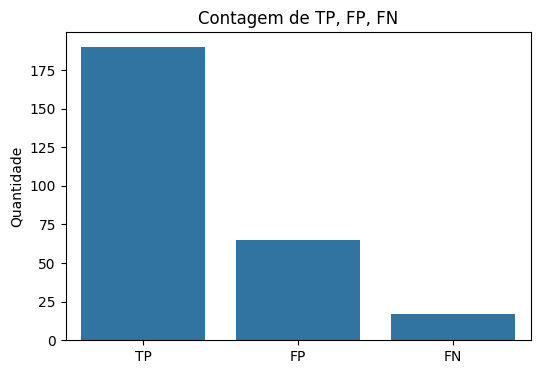

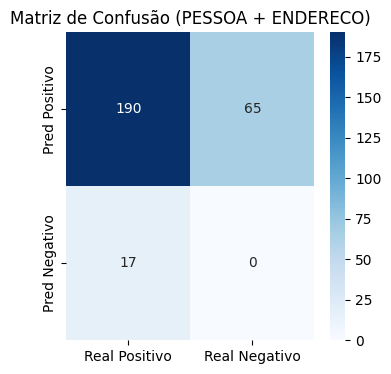

In [15]:
calcular_metricas('./saida/legalbert/resultado_final(person_location)-20_legalbert.json', anotacoes, './saida/legalbert/métricas_legalbert-20.txt')

QUALITATIVA

In [16]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

def analise_qualitativa(pred_path, anotacoes, output_path="resultado_qualitativa.txt", margem_erro=30):
    with open(pred_path, 'r', encoding='utf-8') as f:
        predicoes = json.load(f)

    chaves_comuns = set(predicoes.keys()) & set(anotacoes.keys())

    resumo = {
        "CAIXA": 0,
        "PREV_MENOR": 0,
        "PREV_MAIOR": 0,
        "FALSO_POSITIVO": 0,
        "FALSO_NEGATIVO": 0
    }

    detalhes = {chave: [] for chave in resumo}

    # NOVO: contadores de entidades anotadas e preditas
    total_anotacoes = {"PESSOA": 0, "ENDERECO": 0}
    total_predicoes = {"PESSOA": 0, "ENDERECO": 0}

    for doc_id in chaves_comuns:
        for ent in anotacoes[doc_id]:
            if ent["tipo"] in total_anotacoes:
                total_anotacoes[ent["tipo"]] += 1
        for ent in predicoes.get(doc_id, []):
            if ent["tipo"] in total_predicoes:
                total_predicoes[ent["tipo"]] += 1

    with open(output_path, "w", encoding="utf-8") as arquivo:
        arquivo.write(f"Comparando {len(chaves_comuns)} documentos em comum.\n\n")

        arquivo.write("===== TOTAL DE ENTIDADES =====\n")
        arquivo.write(f"- Anotações:\n")
        for tipo, total in total_anotacoes.items():
            arquivo.write(f"  - {tipo}: {total}\n")
        arquivo.write(f"- Predições:\n")
        for tipo, total in total_predicoes.items():
            arquivo.write(f"  - {tipo}: {total}\n")
        arquivo.write("\n")

        for doc_id in chaves_comuns:
            verdadeiras = [
                (ent["inicio"], ent["fim"], ent["tipo"], ent.get("texto", ""))
                for ent in anotacoes[doc_id]
                if ent["tipo"] in ["PESSOA", "ENDERECO"]
            ]
            preditas = [
                (ent["inicio"], ent["fim"], ent["tipo"], ent.get("texto", ""))
                for ent in predicoes.get(doc_id, [])
                if ent["tipo"] in ["PESSOA", "ENDERECO"]
            ]

            matched_preds = set()
            matched_verdadeiras = set()

            for i, (v_ini, v_fim, v_tipo, v_texto) in enumerate(verdadeiras):
                matched = False
                for j, (p_ini, p_fim, p_tipo, p_texto) in enumerate(preditas):
                    if j in matched_preds:
                        continue
                    if (
                        v_tipo == p_tipo and
                        v_ini < p_fim and p_ini < v_fim and
                        abs(v_ini - p_ini) <= margem_erro and
                        abs(v_fim - p_fim) <= margem_erro
                    ):
                        matched_preds.add(j)
                        matched_verdadeiras.add(i)
                        matched = True

                        if (
                            v_texto.lower() == p_texto.lower()
                            or (v_ini, v_fim) == (p_ini, p_fim)
                        ):
                            tipo = "CAIXA"
                        elif v_texto.lower() in p_texto.lower():
                            tipo = "PREV_MAIOR"
                        elif p_texto.lower() in v_texto.lower():
                            tipo = "PREV_MENOR"
                        else:
                            tipo = "PREV_MAIOR"

                        resumo[tipo] += 1
                        detalhes[tipo].append((doc_id, v_ini, v_fim, v_tipo, v_texto, p_ini, p_fim, p_tipo, p_texto))
                        break

                if not matched:
                    resumo["FALSO_NEGATIVO"] += 1
                    detalhes["FALSO_NEGATIVO"].append((doc_id, v_ini, v_fim, v_tipo, v_texto, None, None, None, None))

            for j, (p_ini, p_fim, p_tipo, p_texto) in enumerate(preditas):
                if j not in matched_preds:
                    resumo["FALSO_POSITIVO"] += 1
                    detalhes["FALSO_POSITIVO"].append((doc_id, None, None, None, None, p_ini, p_fim, p_tipo, p_texto))

        arquivo.write("\n===== RESUMO QUALITATIVO =====\n")
        legendas = {
            "CAIXA": "Início e fim iguais ou texto igual ignorando maiúsculas/minúsculas",
            "PREV_MENOR": "Texto da predição é menor, contido na anotação",
            "PREV_MAIOR": "Texto da predição é maior, contém a anotação",
            "FALSO_POSITIVO": "Predição sem correspondente na anotação (falso positivo)",
            "FALSO_NEGATIVO": "Anotação sem correspondente na predição (falso negativo)"
        }

        for k, v in resumo.items():
            descricao = legendas.get(k, "")
            arquivo.write(f"- {k}: {v}  →  {descricao}\n")

        for tipo, ocorrencias in detalhes.items():
            if ocorrencias:
                arquivo.write(f"\n\n==== CASOS {tipo} ====\n")
                for item in ocorrencias:
                    doc_id, v_ini, v_fim, v_tipo, v_texto, p_ini, p_fim, p_tipo, p_texto = item
                    arquivo.write(f"\nDocumento: {doc_id}\n")
                    arquivo.write(f"  anotacao: ({v_ini}, {v_fim}, {v_tipo}, '{v_texto}')\n" if v_ini is not None else "  anotacao: ---\n")
                    arquivo.write(f"  pred:     ({p_ini}, {p_fim}, {p_tipo}, '{p_texto}')\n" if p_ini is not None else "  pred:     ---\n")

    print("\n===== TOTAL DE ENTIDADES =====")
    print("- Anotações:")
    for tipo, total in total_anotacoes.items():
        print(f"  - {tipo}: {total}")
    print("- Predições:")
    for tipo, total in total_predicoes.items():
        print(f"  - {tipo}: {total}")

    print("\n===== RESUMO QUALITATIVO =====")
    for k, v in resumo.items():
        descricao = legendas.get(k, "")
        print(f"- {k}: {v}  →  {descricao}")

    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(resumo.keys()), y=list(resumo.values()))
    plt.title("Análise Qualitativa das Entidades")
    plt.ylabel("Contagem")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



===== TOTAL DE ENTIDADES =====
- Anotações:
  - PESSOA: 197
  - ENDERECO: 10
- Predições:
  - PESSOA: 228
  - ENDERECO: 27

===== RESUMO QUALITATIVO =====
- CAIXA: 179  →  Início e fim iguais ou texto igual ignorando maiúsculas/minúsculas
- PREV_MENOR: 3  →  Texto da predição é menor, contido na anotação
- PREV_MAIOR: 8  →  Texto da predição é maior, contém a anotação
- FALSO_POSITIVO: 65  →  Predição sem correspondente na anotação (falso positivo)
- FALSO_NEGATIVO: 17  →  Anotação sem correspondente na predição (falso negativo)


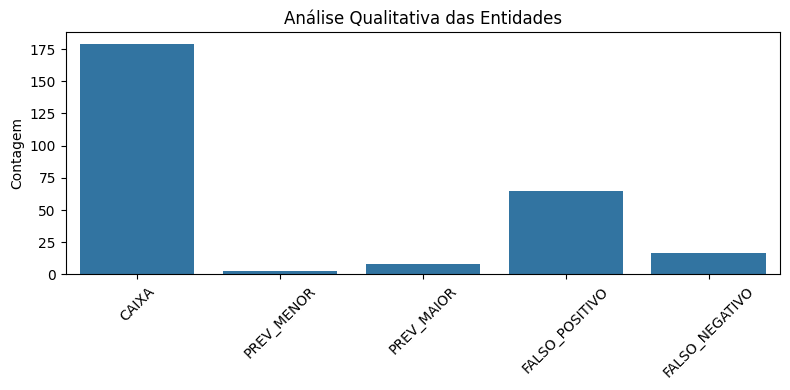

In [17]:
analise_qualitativa('./saida/legalbert/resultado_final(person_location)-20_legalbert.json', anotacoes, './saida/legalbert/qualitativa_legalbert-20-v2.txt')